# 欧式距离

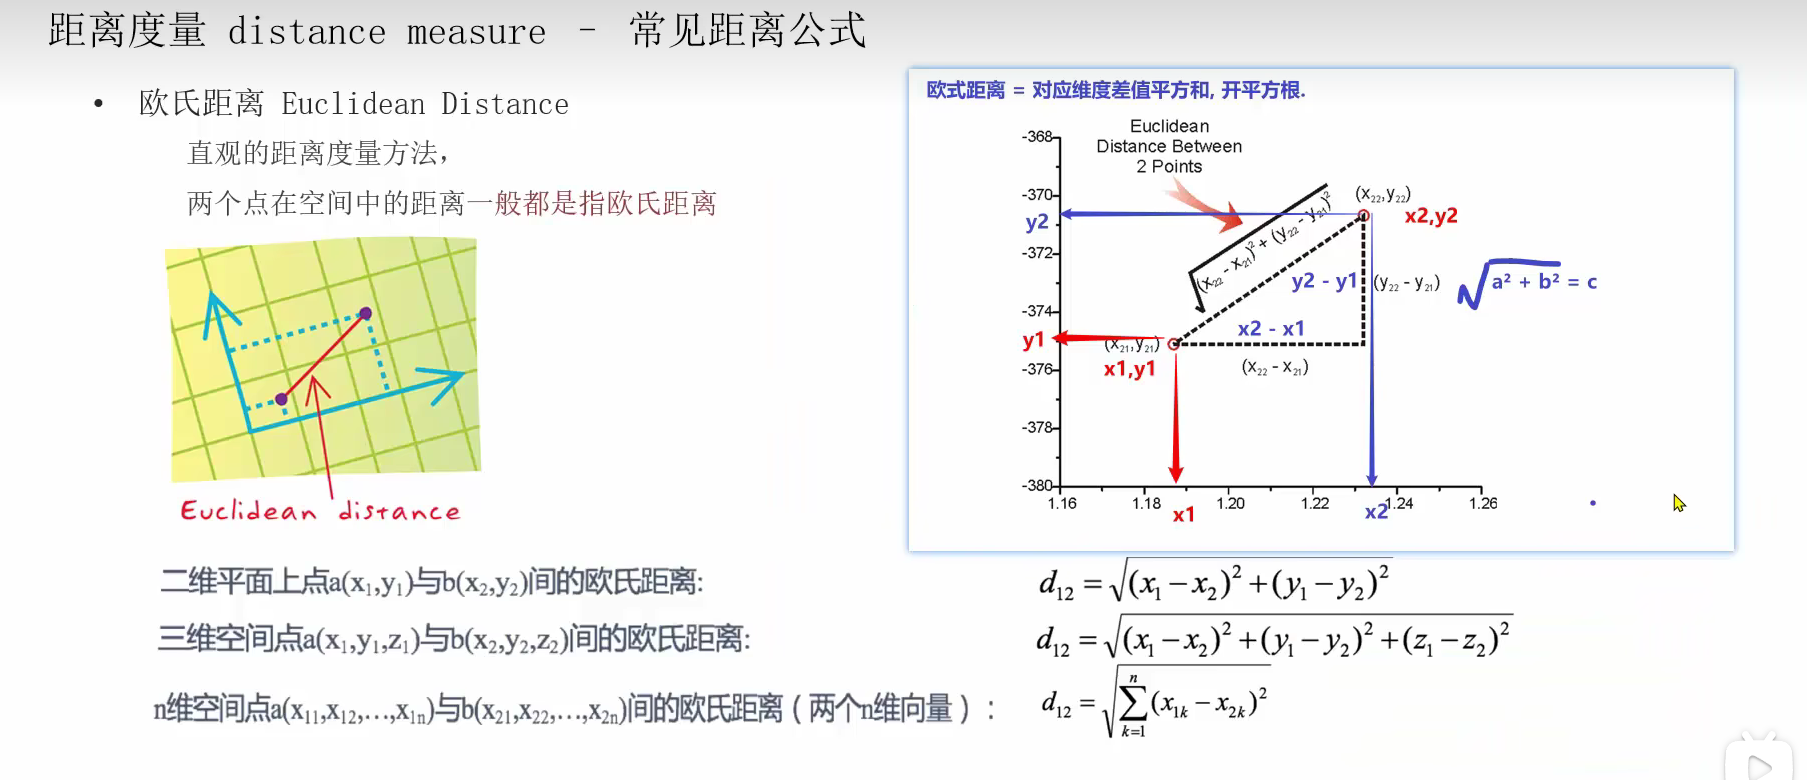

# 曼哈顿距离（城市街区距离）

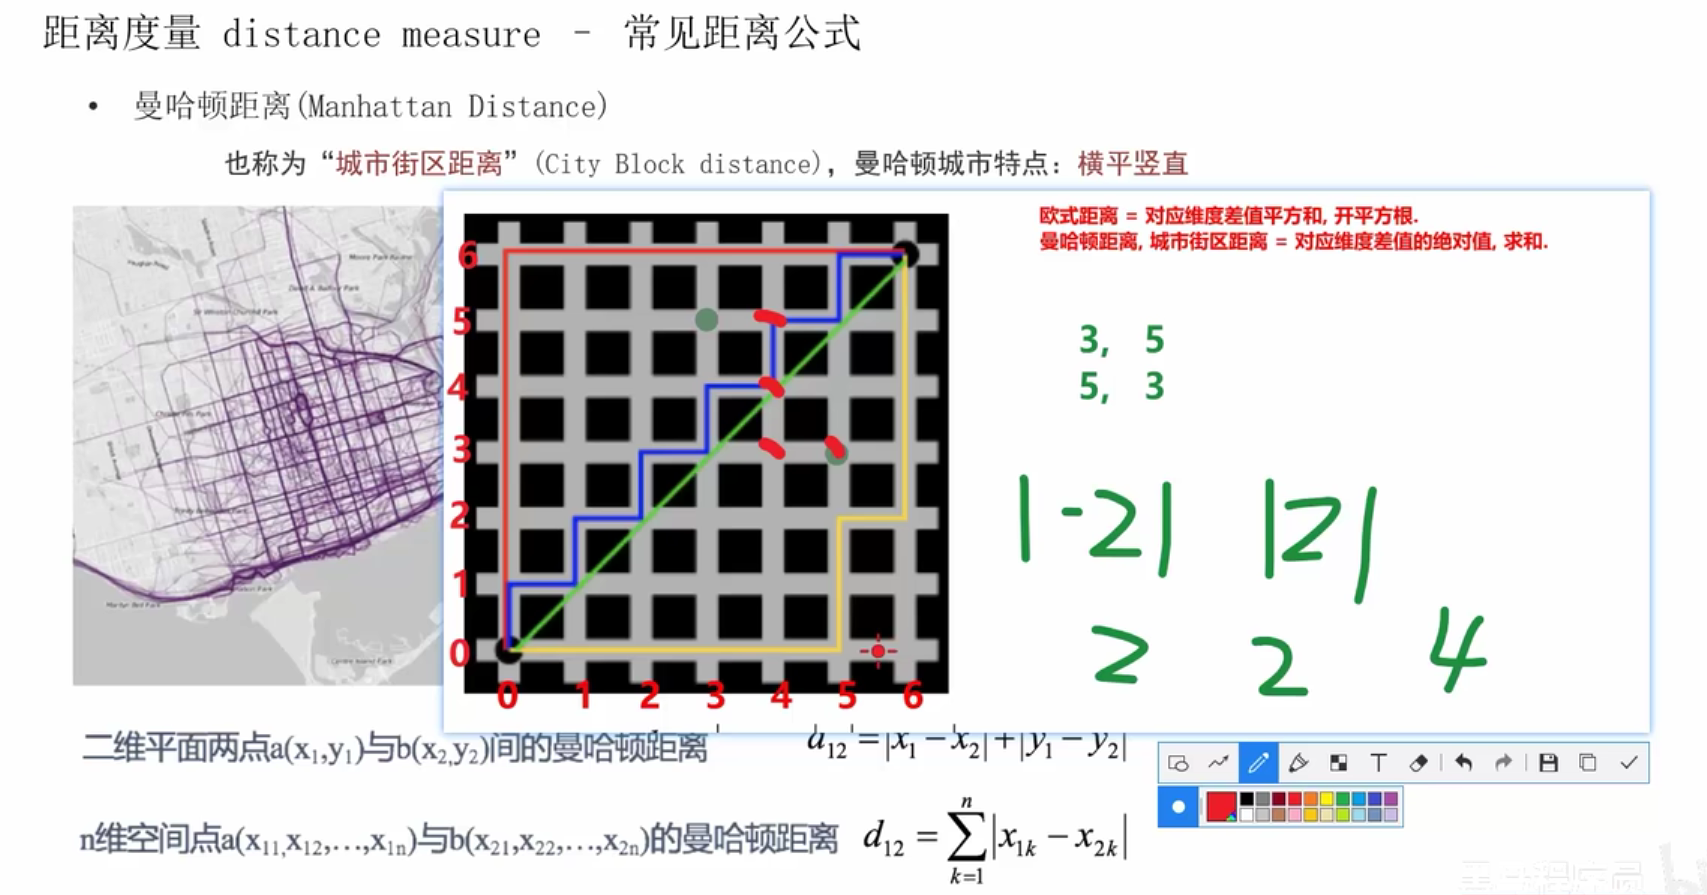

特点是横平竖直 公式类似于欧式 一个是一次方 一个是二次方 一个开一次方 一个开二次方
从坐标点（0，0）到（6，6）一共用了12步 利用曼哈顿公式计算 可以算任意坐标点到另一个坐标点的步数
（3，5）到（5，3）同理

# 切比雪夫距离

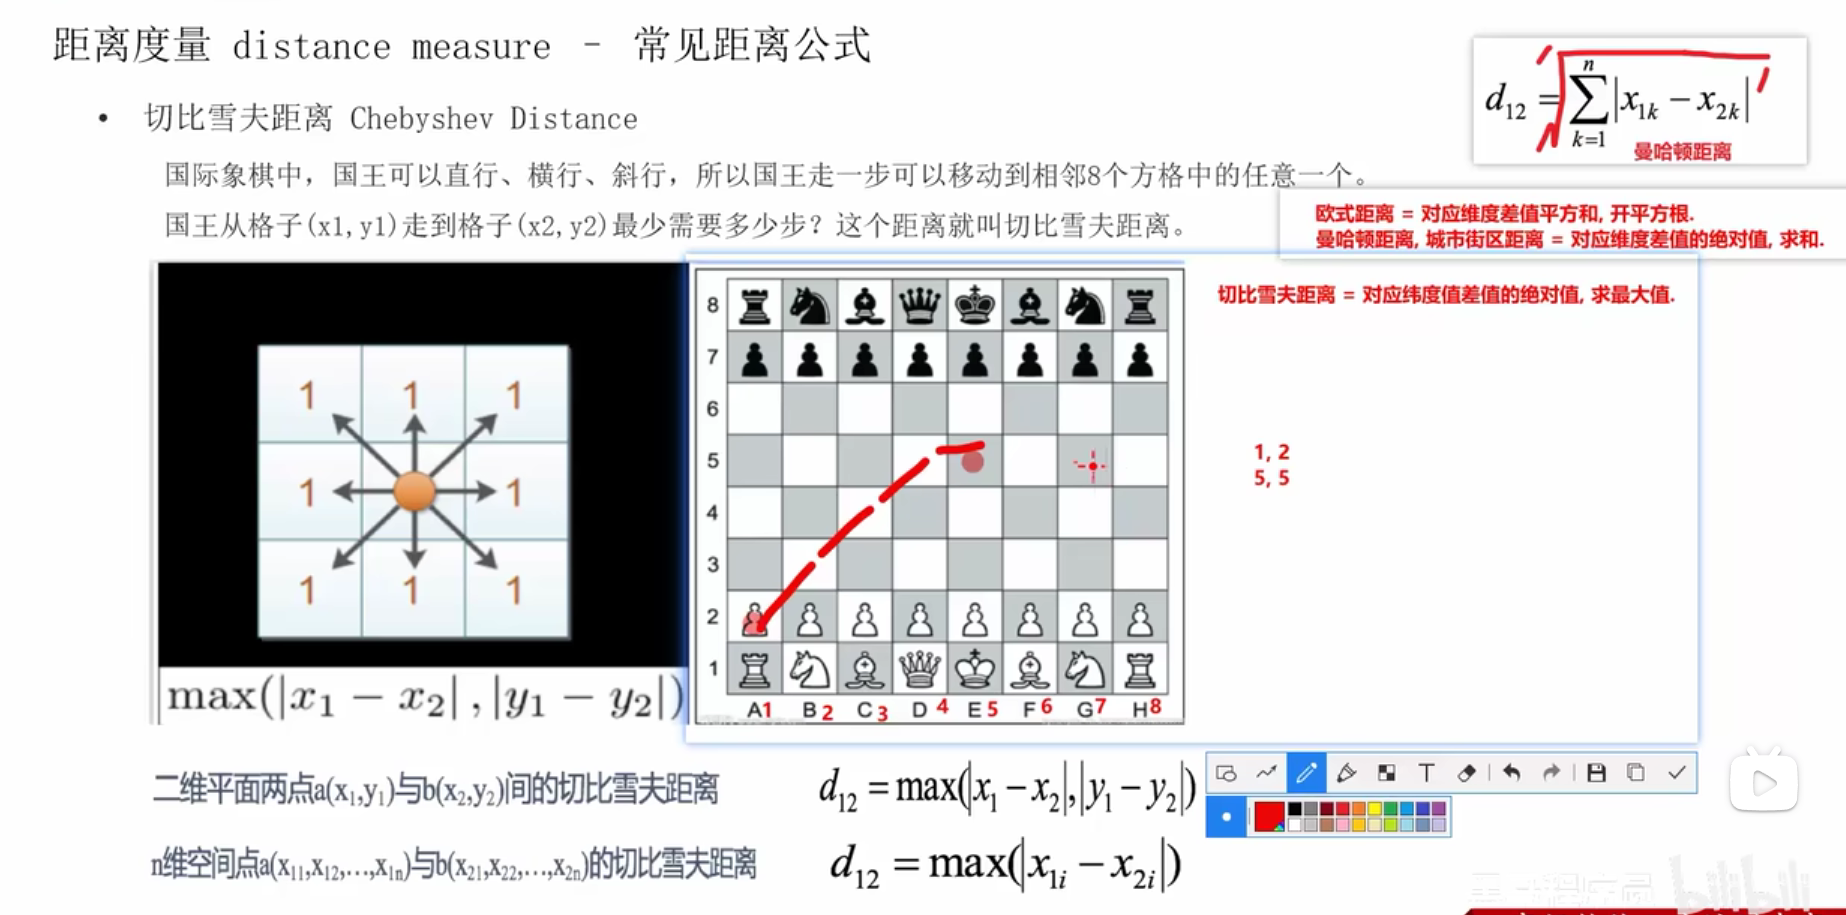
求差值的最大值
一个格子可以有八个方向

# 闵氏距离

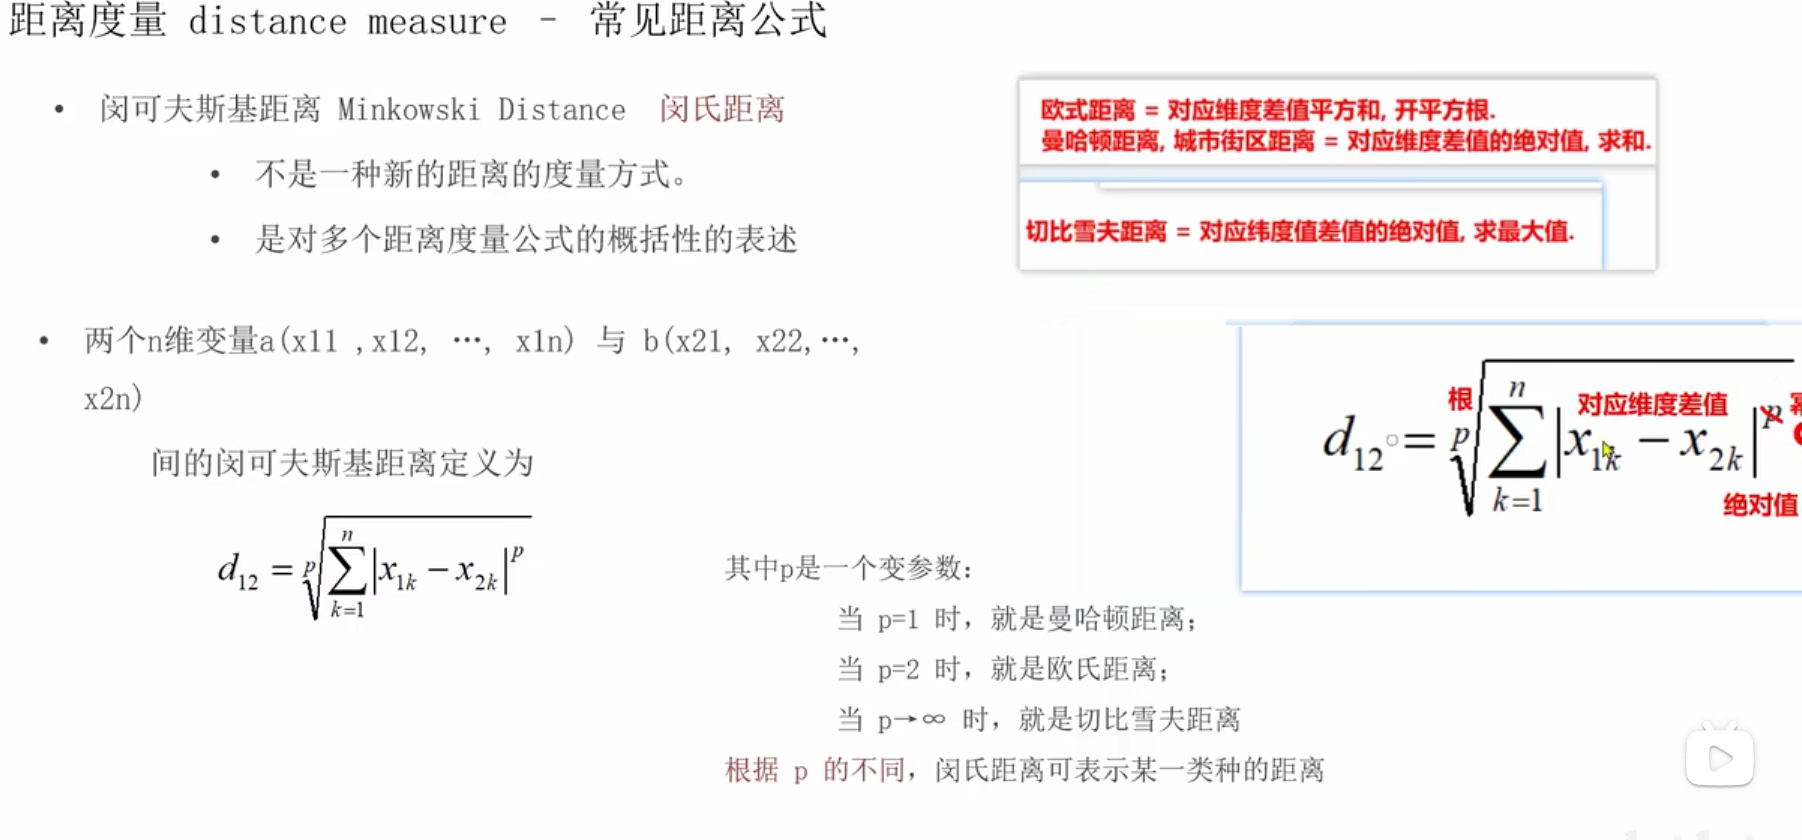

# 🚀 自动化调参神器 Optuna 从零到精通指南

如果你厌倦了用 `GridSearchCV`（网格搜索）像老牛犁地一样缓慢地遍历参数，或者觉得 `RandomSearchCV`（随机搜索）纯靠玄学碰运气，那么 **Optuna** 就是为你量身定制的“智能调参黑科技”。

本篇指南将从**核心原理**、**API 详解**到**代码实战**为你全方位拆解

---

## 一、 Optuna 的三大核心底层原理

Optuna 之所以能在一众调参框架（如 Hyperopt, Ray Tune）中脱颖而出，核心在于它解决了传统调参框架的痛点。

### 1. 核心概念：Study（实验）与 Trial（试验）
Optuna 的架构主要由三个概念组成：
* **Objective Function（目标函数）：** 你需要优化的任务（例如：训练一个模型并返回验证集上的 Loss 或 Accuracy）。
* **Trial（单个试验）：** 目标函数的一次执行过程。在这一步中，Optuna 会为你“猜”一组参数。
* **Study（优化实验）：** 包含一系列 Trial 的总称，负责管理整个调优生命周期、保存历史记录并决定下一步怎么“猜”。

### 2. Define-by-Run（即时定义）
这是 Optuna 最具革命性的特点。传统的框架（如 Hyperopt）需要你在运行前把整个搜索空间（Search Space）硬编码写死。而 Optuna 采用 **Define-by-Run** 机制，这意味着**搜索空间是在代码运行过程中动态生成的**。

> 💡 **通俗来说：** 你可以在代码里写 `if` 条件语句！如果参数 A 选了 `Method_X`，那么接下来才去采样参数 B；如果选了 `Method_Y`，则根本不创建参数 B 的搜索空间。这种动态性极大地方便了复杂网络结构（如 NAS 神经网络架构搜索）的调整。

### 3. 高效的采样与剪枝算法（核心智商所在）
Optuna 绝不是盲目乱猜，它拥有两大核心武器：
* **TPE 采样算法 (Tree-structured Parzen Estimator)：** 基于贝叶斯优化原理。它会根据以往 Trial 的表现，将参数空间划分为“好参数区”和“坏参数区”。计算新参数属于好参数区的概率，公式化表示为寻找使下式最大化的参数 $x$：
    $$\alpha(x) = \frac{\ell(x)}{g(x)}$$
    其中 $\ell(x)$ 是好参数的密度函数，$g(x)$ 是坏参数的密度函数。它能让你越猜越准。
* **Pruning（自动剪枝/早停机制）：**
    如果一个 Trial 在刚跑完前几个 Epoch（轮次）时的表现就已经明显劣于历史平均水平，Optuna 会**果断掐断这个 Trial**，不再浪费算力。在微调大模型或训练深层网络时，这能帮你省下大量的算力和时间。

---

## 二、 核心 API 极其参数速查

在写代码前，我们先搞懂 Optuna 最常用的 API 接口。

### 1. 参数建议器 (Trial Suggest API)
在目标函数内部，我们通过 `trial` 对象来定义参数的范围和类型：

| 方法 | 适用场景 | 关键参数举例 |
| :--- | :--- | :--- |
| `trial.suggest_float(name, low, high, log=False)` | 连续型浮点数（如学习率） | `log=True` 适合跨越多个数量级的参数（如 0.0001 到 0.1） |
| `trial.suggest_int(name, low, high, step=1)` | 整数型参数（如树的棵树、层数） | `step=2` 可以只采样偶数 |
| `trial.suggest_categorical(name, choices)` | 离散分类/标签（如激活函数、优化器） | `choices=['adam', 'sgd', 'rmsprop']` |

### 2. 实验管理 API
* `optuna.create_study(direction="minimize")`: 创建实验。`direction` 可选 `"minimize"`（算 Loss） 或 `"maximize"`（算 Accuracy）。
* `study.optimize(objective, n_trials=100)`: 开始跑大盘。执行 100 次试验。
* `study.best_params`: 吐出当前最好的那组参数。
* `study.best_value`: 吐出最好的参数对应的目标函数得分。

---


## 四、 炫酷的可视化看板（复盘神器）

Optuna 内置了极其强大的可视化模块，只需要几行代码就能生成交互式图表。
*(注：运行以下代码需要安装 `pip install plotly`)*

```python
# 1. 查看调参的历史收敛轨迹（看它是不是在一步步变好）
optuna.visualization.plot_optimization_history(study)
```

```python
# 2. 查看参数的高维超空间交互图（揪出参数之间的羁绊）
optuna.visualization.plot_parallel_coordinate(study)
```

```python
# 3. 极其重要：查看超参数权重/重要性（看哪个参数对模型影响最大）
optuna.visualization.plot_param_importances(study)
```

---

## 五、 核心总结大礼包

用一句话概括 Optuna 的工作流：**写个带 `trial.suggest_xxx` 的函数，丢给 `study.optimize` 让他自己去猜，最后看 `study.best_params` 抄作业。**

### 💡 避坑与进阶小 Tips：
1. **多进程并发：** Optuna 支持分布式调参。只需将 `create_study` 里的持久化配置改为数据库（例如 `storage="sqlite:///db.sqlite3"`），你就可以在终端同时开多个 Python 脚本或 Notebook 跑同一个实验，它们会自动共享数据。
2. **避开不合理的区间：** 哪怕是初学，也尽量把 `log=True` 用在那些呈指数级变化的超参数上（如学习率、正则化系数），这能帮 TPE 算法节约海量的早期探索时间。
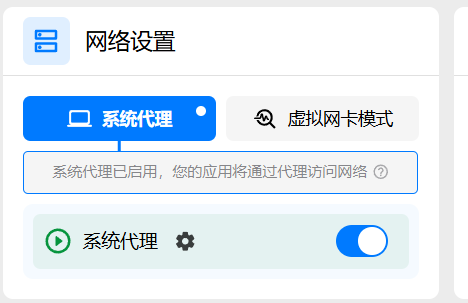

optuna框架 ： 相对于叫交叉验证网格搜索 它只需要给一个参数范围 他就可以自己取寻找最佳参数 先猜再训练 根据猜的各个参数 分为好参区和坏参区 用好参的概率比上坏参的概率 使这个公式最大化 就可以越才越准

# 📊 探索性数据分析 (EDA) 总结与风控业务复盘

在本项目中，我们针对 **2021年 MachineHack 德勤（Deloitte）机器学习挑战赛 - 贷款违约预测数据集** 展开了深度的探索性数据分析（EDA）。本数据集包含 67,463 条训练样本，共 35 个特征维度。

---

## 🛑 核心发现：脱敏数据集的“数据错位与加噪”现象

在初筛阶段，我们发现了非常反常的金融业务逻辑：部分样本的 `Funded Amount`（实际放款额）和 `Funded Amount Investor`（投资人出资额）居然显著大于 `Loan Amount`（申请金额），甚至出现了“申请 1 万给 3 万多”的现象。

* **成因剖析**：由于该数据集属于商业竞赛性质，主办方德勤（Deloitte）为了保护银行真实商业机密和用户隐私，在发布前对数值型特征进行了**高强度的匿名化脱敏与人工加噪处理**。
* **特征工程对策**：由于上述三个金额字段的单行具体数值已丧失传统的贷前级联业务逻辑，且极易引发严重的共线性干扰，我们在特征清洗阶段果断**直接剔除（Drop）**了受到严重噪声干扰的贷中金额字段（`Funded Amount`、`Funded Amount Investor`），只保留硬通货贷前特征，以确保模型的鲁棒性。

---

## 🛠️ 工业界最常用的三板斧 EDA 策略

在真实的金融风控和机器学习开发中，我们主要通过以下三套核心组合拳来榨取数据的分布信号：

### 1️⃣ 单变量大盘审视（极致偷懒法）
* **业务逻辑**：在刚拿到未知的新数据集时，第一时间利用自动化大盘工具（如 `sweetviz` 或 `ydata-profiling`）进行一键式扫描。
* **核心价值**：只需一行代码，即可自动生成包含所有特征的柱状图、直方图、缺失值占比及统计学指标的全局可视化报告，极大提升了前期清洗和探索的效率。

### 2️⃣ 目标标签（Loan Status）分布校验
* **业务逻辑**：使用 `value_counts(normalize=True)` 观察 `0`（正常还款）与 `1`（违约逾期）的绝对数量与百分比。
* **核心价值**：风控场景天然具备**高度的样本不均衡性**（通常坏人占比极低）。提早明确不均衡比例，能为后续模型选择（如是否引入 SMOTE 过采样、调整 XGBoost 的 `scale_pos_weight` 权重参数或换用更合理的评价指标 AUC/F1-Score）奠定基调。

### 3️⃣ 好坏人群差异性对比 🌟【建模最核心的一步】
* **大白话业务逻辑**：利用 `df.groupby('Loan Status').mean()`，把数据集像切西瓜一样分成“按时还钱的好人组”和“逾期不还的坏人组”，然后去对比他们各项指标的平均值。
* **为什么一定要做这一步？**：
    * **提前找出强力特征**：如果某个特征（比如负债率），好人平均只有 15%，坏人平均高达 45%，说明这个特征有极强的“辨别能力”。后面的树模型（XGBoost）最喜欢这种特征，会优先用它来设置“风控关卡”切分人群。
    * **发现隐藏的黑天鹅**：有时候会跑出反直觉的规律，比如“提交了严格收入证明的人，违约率反而更高”。这在金融里很常见，因为只有本身资质差、负债高的人，平台才会强行逼着他去开各种证明。
## 总结
1   **先看标签分布**：`df['Loan Status'].value_counts()` $\rightarrow$ 确认好坏比，心里对样本不均衡程度有个数。

2   **再看特征整体分布**：`df.describe()` 和 `df.hist()` $\rightarrow$ 检查有没有长尾分布、极端大数（比如 99999）或者负数的异常值。

3   **最后看特征交叉分布**：`df.groupby('Loan Status').mean()` $\rightarrow$ 找出哪几个特征在好坏人之间差距最明显，锁定制胜的核心特征。

# 📊 金融风控特征工程：数据“盖帽法”（Winsorization）详解

## 1. 什么是“盖帽法”？（一句话大白话）
**盖帽法（Winsorization）**，又叫**分位数截断/强行拉回法**。
它的核心思想是：**不删除异常值，而是给数据的上限和下限“封顶”，把超出正常范围的极端大数或极端小数，强行变成设定的临界值。**

---

## 2. 为什么要用它？（业务痛点）
在金融风控场景中（比如预测贷款违约），借款人的**年收入（Salary）**、**总资产余额**往往存在极端的异常值。
* **直接留着它？** 逻辑回归（LR）等模型会被一两个资产几亿的“天外飞仙”样本直接带偏，导致普通人的评分体系崩溃。
* **直接删掉它？** 风控里每一个样本（尤其是违约的坏人样本）都是真金白银买来的，乱删数据会导致样本量不足。

**💡 盖帽法的完美解法：** 它“既不纵容异常值，也不物理删除样本”，而是把极端值**“劝回”**到正常人的最高/最低边界。

---

## 3. 核心硬核案例（10对10完美还原）

假设你有 10 个借款人的年收入数据（单位：万元）：
> `[0.001, 10, 20, 30, 40, 50, 60, 70, 80, 10000]`

这里有两个明显的异常值：一个是接近于 0 的 `0.001`（极小值），一个是高到离谱的 `10000`（极大值）。

现在我们设置 **下限为 10% 分位数（lower_pct=0.1）**，**上限为 90% 分位数（upper_pct=0.9）**：

1. **第一步：代码寻找边界（Quantile）**
   * 从小到大数，排在倒数第一个（10%位置）的数字刚好是 **`10`**。
   * 排在正数第九个（90%位置）的数字刚好是 **`80`**。
   * 代码在后台拿到了指甲刀的两个边界：`[10, 80]`。

2. **第二步：一键修剪（Clip）**
   * 扫描到 `0.001`：比 10 小，**强行拉高变成 10**。
   * 扫描到 `10000`：比 80 大，**强行剪平变成 80**。
   * 中间的 `20, 30, 40, 50, 60, 70, 80`：全在安全区间内，**原地不动**。

3. **盖帽法处理后的最终数据：**
   > `[10, 10, 20, 30, 40, 50, 60, 70, 80, 80]`

* **神奇的效果**：
  * 修改前平均值：**`1036`**（完全被一万带偏，毫无参考价值）
  * 修改后平均值：**`44`**（非常完美地落在了这组数据的真实中心）

---

## 4. 工业界最常用的标准：1% 与 99%
在实际做大数据集（如几万条的贷款数据）时，我们通常只剪掉最极端的两头：
* **下限（1% 分位数）**：排在全员最后 1% 的极低值（变成 1% 那个位置的数字）。
* **上限（99% 分位数）**：排在全员最前 1% 的极高值（变成 99% 那个位置的数字）。

---

## 5. 工业级 Python 实战代码

在 Pandas 中，我们使用 `.quantile()` 来寻找边界，使用 `.clip()` 把两端多余的异常值一键截断。

```python
import pandas as pd

def winsorize_series(series, lower_pct=0.01, upper_pct=0.99):
    """
    对单列特征进行盖帽法处理的通用函数
    """
    # 1. 算出指定的低位和高位临界值（比如 1% 和 99%）
    lower_bound = series.quantile(lower_pct)
    upper_bound = series.quantile(upper_pct)

    # 2. 用 clip 函数一键截断并拉回
    # lower 代表低于这个值的变成本值，upper 代表高于这个值的变成本值
    return series.clip(lower=lower_bound, upper=upper_bound)

# --- 真实项目调用示例 ---
## 假设 df_cleaned 是你的数据集，我们对 'Salary'（年收入）进行 99% 盖帽
df_cleaned['Salary'] = winsorize_series(df_cleaned['Salary'], lower_pct=0.01, upper_pct=0.99)
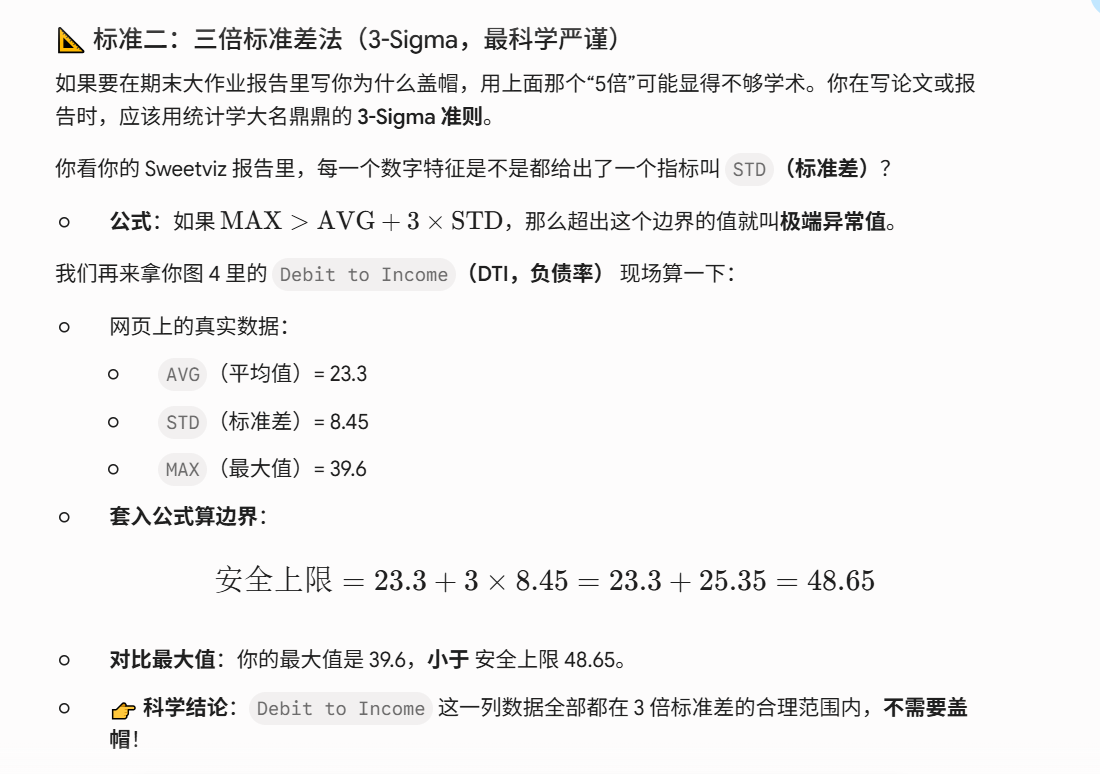

# 盖帽法使用条件
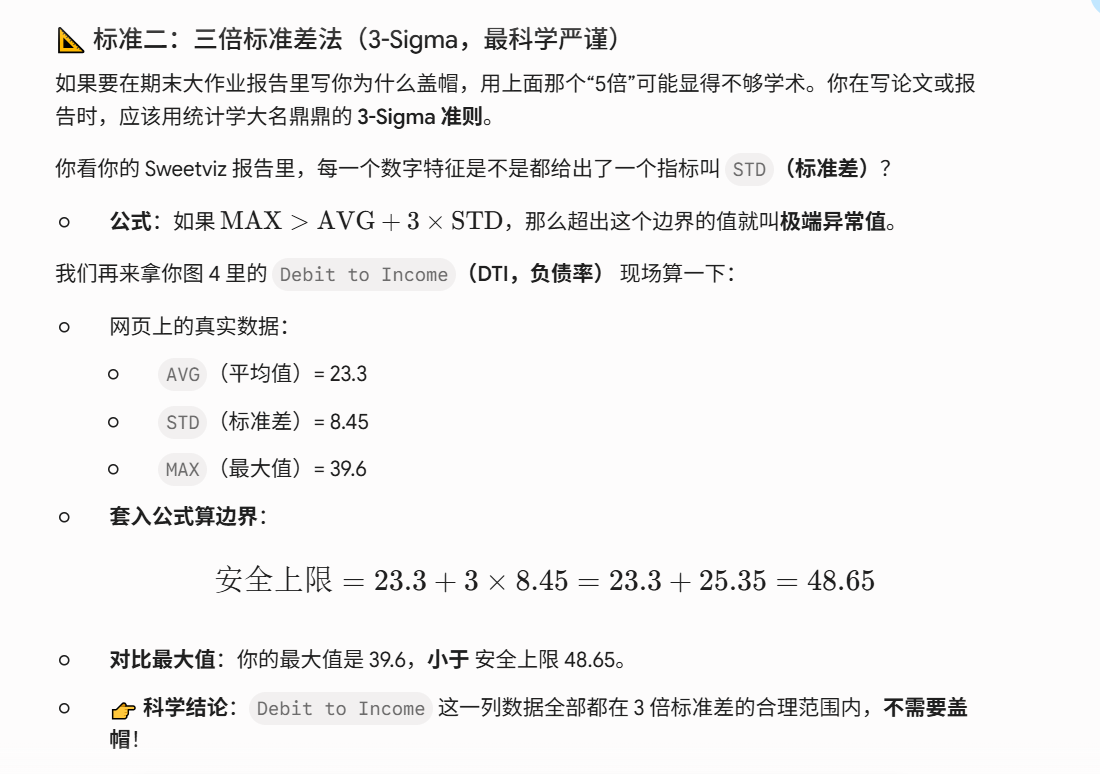

# 🏷️ 机器学习特征工程：独热编码（One-Hot Encoding）速查笔记

## 1. 什么是独热编码？（大白话）
独热编码是用来**把“文本/类别型”数据变成“数字”**的一种标准方法。
它会为该特征下的每一个类别单独创建一列，**哪一列符合，哪一列就填 `1`，其余列填 `0`**。因为每行有且仅有一个格子是 `1`（是热的），所以叫“独热”。

---

## 2. 核心案例对比

假设你的数据集中有一列特征叫 `HomeOwnership`（住房所有权），里面有三个类别：`Rent`（租房）、`Own`（全款房）、`Mortgage`（房贷中）。



### 🔄 编码前 $\rightarrow$ 编码后：

| 原始列：HomeOwnership | ➡️ | 新列：HomeOwnership_Mortgage | 新列：HomeOwnership_Own | 新列：HomeOwnership_Rent |
| :--- | :---: | :---: | :---: | :---: |
| **Rent**（租房） | ➡️ | 0 | 0 | **1** |
| **Own**（有房） | ➡️ | 0 | **1** | 0 |
| **Mortgage**（房贷）| ➡️ | **1** | 0 | 0 |
| **Rent**（租房） | ➡️ | 0 | 0 | **1** |

---

## 3. 黄金判断法则：什么列“需要”做独热编码？

你在盯数据集时，满足以下两个条件的列，直接闭眼做独热：

1. **类别之间没有大小高低顺序（无序分类）**：
   * ✅ **适合独热**：`HomeOwnership`（租房/有房）、`Application Type`（个人/联合申请）。它们是平等的。
   * ❌ **不适合独热**：`Grade`（贷款评级 A, B, C, D）。因为 $A > B > C > D$，自带等级顺序，独热会破坏大小关系（这种应该用标签编码 `1, 2, 3, 4`）。
2. **这一列的不同类别总数不能太多（基数小）**：
   * 工业界潜规则：**不同类别数 $\le 10$ 个**的列最适合做独热。如果是像 `Loan Title`（贷款用途）这种里面包含几千种文本的列，做独热会导致特征列瞬间爆炸（维度灾难），不建议做。

---

## 4. Python 实战核心代码

在 Pandas 中，我们使用超级简便的 `pd.get_dummies()` 来一键搞定：

```python
import pandas as pd

# 假设 df_cleaned 是你的数据集
# 对 'HomeOwnership' 和 'Application Type' 两个文本列进行独热编码
# drop_first=True 是工业界标准，能够删掉多余的第一列，防止多重共线性（比如 0和1 就能表达性别，不需要两列）
df_cleaned = pd.get_dummies(df_cleaned, columns=['HomeOwnership', 'Application Type'], drop_first=True)

# 💡 怎么判断成功了？
# 运行后打印 df_cleaned.head()，如果原本的文本列消失，变成了带下划线的 0和1 新列，即代表完美成功！

# 类别特征编码（One-Hot 与 Label Encoding）判断流程

## 一、总体原则

对于机器学习中的类别变量，不应简单根据 `dtype=object` 就全部进行独热编码，而应结合业务含义、类别数量以及是否存在顺序关系进行判断。

编码决策流程如下：

```text
类别变量
│
├── 是否存在顺序关系？
│
├── 是
│   └── 标签编码（Ordinal Encoding）
│
└── 否
    │
    ├── 类别数量 ≤ 10
    │   └── One-Hot编码
    │
    ├── 类别数量 10~30
    │   └── 视情况进行One-Hot编码
    │
    └── 类别数量 > 30
        └── 删除 / 目标编码 / CatBoost处理
```

---

# 二、查看所有类别变量

首先查看所有类别特征及其唯一值数量：

```python
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f'\n{col}')
    print(f'唯一值数量：{df[col].nunique()}')
    print(df[col].value_counts().head())
```

或者查看全部字段：

```python
for col in df.columns:
    print(
        f'{col:<35}',
        f'dtype={df[col].dtype}',
        f'nunique={df[col].nunique()}'
    )
```

---

# 三、标签编码（Label Encoding）

适用于：

* 类别之间存在明显顺序关系
* 数值大小具有实际业务意义

例如：

```text
A > B > C > D > E > F > G
```

```text
小学 < 初中 < 高中 < 大学 < 研究生
```

```text
低风险 < 中风险 < 高风险
```

示例：

```python
grade_map = {
    'A':7,
    'B':6,
    'C':5,
    'D':4,
    'E':3,
    'F':2,
    'G':1
}

df['Grade'] = df['Grade'].map(grade_map)
```

---

# 四、One-Hot编码

适用于：

* 类别之间不存在大小关系
* 类别数量较少（一般 ≤ 10）

例如：

```text
RENT
OWN
MORTGAGE
OTHER
```

不能认为：

```text
OWN > RENT
```

因此需要独热编码：

```python
df = pd.get_dummies(
    df,
    columns=['Home Ownership'],
    drop_first=True
)
```

生成：

```text
Home_OWN
Home_RENT
Home_MORTGAGE
```

---

# 五、高基数类别变量

如果类别数量过多：

```python
df['Loan Title'].nunique()
```

例如：

```text
200
500
1000
```

则不建议One-Hot编码。

原因：

```text
1列
↓
扩展成数百列
↓
维度爆炸
```

解决方案：

* 删除该特征
* Target Encoding（目标编码）
* CatBoost直接处理

---

# 六、常见判断口诀

## 问自己一句：

如果把该变量编码为：

```text
1
2
3
4
```

数字大小是否具有实际业务意义？

### 如果有意义

使用：

```text
Label Encoding
```

例如：

```text
学历
风险等级
贷款评级
```

---

### 如果没有意义

使用：

```text
One-Hot Encoding
```

例如：

```text
城市
职业
住房状态
申请类型
```

---

# 七、贷款违约预测项目实例

| 特征                  | 推荐处理方式    |
| ------------------- | --------- |
| Grade               | 标签编码      |
| Sub Grade           | 标签编码      |
| Term                | 提取数字      |
| Home Ownership      | One-Hot编码 |
| Verification Status | One-Hot编码 |
| Payment Plan        | One-Hot编码 |
| Application Type    | One-Hot编码 |
| Loan Title          | 根据类别数量决定  |
| Interest Rate       | 保持数值型     |
| Loan Amount         | 保持数值型     |
| Salary              | 保持数值型     |
| Debit to Income     | 保持数值型     |

---

# 八、最终经验总结

## 数值变量

```text
不编码
```

---

## 有序类别变量

```text
标签编码（Label Encoding）
```

---

## 无序类别变量且类别较少

```text
One-Hot编码
```

---

## 无序类别变量且类别很多

```text
删除
Target Encoding
CatBoost处理
```

---

## ID类特征

```text
删除
```

---

## 数据泄露特征

```text
删除
```

在实际项目中，不应依赖大量绘图来决定编码方式，而应结合：

* 字段业务含义
* 是否有顺序关系
* 唯一值数量（nunique）

共同判断最合适的编码策略。


# Pandas 类别变量统计与分析

## 1. 统计某一列每个类别出现次数

最常用的方法：

```python
df['Grade'].value_counts()
```

输出示例：

```text
Grade
B    12000
C    10000
A     8000
D     5000
E     2000
```

---

## 2. 查看各类别占比

```python
df['Grade'].value_counts(normalize=True)
```

输出示例：

```text
B    0.35
C    0.29
A    0.23
D    0.10
E    0.03
```

表示：

```text
B类别占35%
C类别占29%
A类别占23%
...
```

---

## 3. 统计时包含缺失值

默认情况下 `value_counts()` 不统计 NaN。

若需要统计缺失值：

```python
df['Grade'].value_counts(dropna=False)
```

输出示例：

```text
A      1000
B       800
NaN      50
```

---

## 4. 查看所有类别变量的分布

查看所有 object 类型列：

```python
for col in df.select_dtypes(include='object').columns:
    print(f'\n===== {col} =====')
    print(df[col].value_counts(dropna=False))
```

输出示例：

```text
===== Home Ownership =====

RENT        25000
MORTGAGE    18000
OWN          8000
OTHER         500

===== Application Type =====

INDIVIDUAL   48000
JOINT         2500
```

---

## 5. 查看唯一值数量

统计不同类别个数：

```python
df['Grade'].nunique()
```

输出：

```text
7
```

表示：

```text
共有7种不同类别
```

---

## 6. 特征工程中最实用的类别变量检查

推荐写法：

```python
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f'\n{col}')
    print(f'唯一值数量: {df[col].nunique()}')
    print(df[col].value_counts(dropna=False))
    print('-' * 50)
```

输出示例：

```text
Grade
唯一值数量: 7

A    15000
B    20000
C    18000
...
--------------------------------------------------

Sub Grade
唯一值数量: 35

A1    2000
A2    1800
...
--------------------------------------------------

Application Type
唯一值数量: 2

INDIVIDUAL    67340
JOINT           123
--------------------------------------------------
```

---

## 7. 编码决策参考

通过观察 `nunique()` 与类别分布，可以快速决定编码方式：

| 特征情况                   | 推荐处理方式               |
| ---------------------- | -------------------- |
| 有顺序类别（Grade、Sub Grade） | 标签编码                 |
| 无顺序且类别数 ≤ 10           | One-Hot编码            |
| 无顺序且类别数 10~30          | 视情况One-Hot           |
| 无顺序且类别数 > 30           | 删除 / Target Encoding |
| 二分类变量                  | map映射为0/1            |
| ID字段                   | 删除                   |
| 数据泄露字段                 | 删除                   |

---

## 8. 实战建议

拿到数据集后优先执行：

```python
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f'\n{col}')
    print(f'唯一值数量: {df[col].nunique()}')
    print(df[col].value_counts(dropna=False))
```

通过查看：

* 类别数量（nunique）
* 类别分布（value_counts）
* 是否存在长尾类别
* 是否存在极度不平衡类别

即可快速完成后续特征工程设计。

这套代码基本可以作为你以后做表格数据（贷款预测、信用评分、用户流失预测等）的固定检查模板。


# 特征工程必背：箱线图（Boxplot）全景解析

箱线图（Boxplot）是数据分析（EDA）和特征工程中展示**连续变量分布**最经典的图表。它的核心作用是：**直观展现数据分布形态、对称性、分散程度，并自动识别异常值。**

---

## 1. 箱线图的“五数概括”与结构

一幅标准的箱线图由一个“箱子”和两根“胡须”组成，完美的对应了统计学中的核心指标：



* **下边缘（Minimum / Whiskers Lower）**：非异常数据的最小值。
* **下四分位数（$Q_1$ / 25th Percentile）**：箱子底部。代表有 25% 的数据比它小。
* **中位数（Median / 50th Percentile）**：箱子中间的横线。代表数据的正中间位置（能免疫极端值的污染）。
* **上四分位数（$Q_3$ / 75th Percentile）**：箱子顶部。代表有 75% 的数据比它小。
* **上边缘（Maximum / Whiskers Upper）**：非异常数据的最大值。
* **异常值（Outliers）**：超出上/下边缘的**孤立点（小圆圈）**。

---

## 2. 核心数学原理：异常值是如何锁定的？

箱线图判定异常值基于严格的统计学 **IQR 准则**：

1.  **计算四分位距（IQR，Interquartile Range）**：即箱子的绝对高度。
    $$IQR = Q_3 - Q_1$$
2.  **设定判定边界（内限）**：
    * **上边界** = $Q_3 + 1.5 \times IQR$
    * **下边界** = $Q_1 - 1.5 \times IQR$
3.  **判定逻辑**：任何 **$X > 边界_{上}$** 或 **$X < 边界_{下}$** 的数据点，一律被标识为**异常值**。

---

## 3. EDA 阶段的黄金应用场景

箱线图的标准数据配比是：**【一个分类变量】 + 【一个连续数值变量】**。

### 场景一：特征 vs 标签（评估预测能力）
* **布局**：X轴 = 分类标签（如 `0`守信 / `1`违约），Y轴 = 数值特征（如 `年收入`）。
* **看点**：看不同标签下的箱子**是否显著错开**。
    * 若错开明显 $\rightarrow$ 该特征区分度极高，是模型的黄金特征。
    * 若高度重合 $\rightarrow$ 该特征对标签没有鉴别力，考虑筛选掉。



### 场景二：特征 vs 特征（挖掘内部关联）
* **布局**：X轴 = 分类特征（如 `房产状态`），Y轴 = 数值特征（如 `贷款利息`）。
* **看点**：验证业务逻辑（如：租房群体的利息箱子是否整体偏高），为衍生交叉特征寻找灵感。

---

## 4. 避坑避用指南

* ❌ **绝对不能用于【数值 vs 数值】**：如果横轴和纵轴都是连续数值（如年收入 vs 贷款金额），会因为横轴类别过多导致画出几万个针尖箱子，图表彻底崩溃。
* 💡 **替代方案**：数值与数值的组合，闭眼去画**散点图（Scatter Plot）**或**热力图（Heatmap）**。

---

## 5. Jupyter 绘图实战代码（Seaborn 版）

在 Notebook 中，推荐使用 `seaborn.boxplot` 快速横向对比多分类下的数值分布，比重叠的直方图更清晰：

```python
import matplotlib.pyplot as plt
import seaborn as sns

# 解决 Jupyter Notebook 中文乱码问题
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制：不同贷款等级(Grade)下的贷款金额(loan_amnt)分布
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grade', y='loan_amnt', data=df, palette='Set2')
#palette='Set2'：指定画图的美化调色盘。Set2 是一套非常经典、清爽的高级哑光色系，能让不同的 Grade 箱子带上不同的高颜值颜色。

plt.title('不同贷款等级的贷款金额分布箱线图', fontsize=14)
plt.xlabel('贷款等级 (Grade)', fontsize=12)
plt.ylabel('贷款金额 (Loan Amount)', fontsize=12)
plt.show()

# 机器学习项目流程笔记

## 一、整体流程

```
EDA（探索性数据分析）
     ↓
异常值检测 + 处理
     ↓
特征转换（正态化）
     ↓
特征工程（衍生 / 分箱 / 编码）
     ↓
特征筛选
     ↓
建模
```

---

## 二、EDA 要做的事

- **单变量分析**：看每个特征的分布（直方图 + KDE曲线）
- **双变量分析**：看特征和目标变量的关系（箱线图）
- **相关性分析**：特征之间有没有高度相关（热力图）
- **缺失值检查**：`df.isnull().sum() / len(df)`
- **目标变量比例**：`df['target'].value_counts(normalize=True)`

---

## 三、异常值处理（IQR 方法）

**原理：**
```
最小值 ----[Q1----中位数----Q3]---- 最大值
IQR=Q1-Q3
低于 Q1 - 1.5×IQR 或 高于 Q3 + 1.5×IQR → 异常值
```

**三种处理方式：**
| 方法 | 适用场景 |
|------|---------|
| 直接删除 | 数据量大，异常值少 |
| **截断 Clip（盖帽异常值变成上限或下限）** | 不想损失数据行数 |
| 替换为中位数 | 异常值较多 |

---

## 四、特征转换（正态化）

**根据偏度选方法：**
| 偏度 | 严重程度 | 推荐方法 |
|------|---------|---------|
| 0.5 ~ 1 | 轻度 | `sqrt(x)` |
| 1 ~ 2 | 中度 | `log1p(x)` |
| > 2 | 重度 | Box-Cox / Quantile |
| 含大量0值 | 特殊 | 二值列 + log |

> ⚠️ 使用树模型（XGBoost / 随机森林）时，正态化**不是必须的**

---

## 五、特征工程

### 5.1 衍生新特征
用现有列组合出更有业务意义的新列：
- `负债率 = 月还款 / 月收入`
- `信用利用率 = 循环余额 / 循环信用额度`
- `每账户平均余额 = 总余额 / 账户数`

### 5.2 分箱处理
把连续变量变成区间标签，捕捉非线性规律：
- 年龄 → 青年 / 中年 / 老年
- 利率 → 低利率 / 中利率 / 高利率

### 5.3 类别特征编码
| 方法 | 适用场景 |
|------|---------|
| One-Hot Encoding | 无序类别，且类别数少 |
| Label Encoding | 有顺序的类别（如学历） |
| Target Encoding | 类别数很多时 |

### 5.4 特征筛选
- **相关性过滤**：两个特征相关性 > 0.9，删一个
- **特征重要性**：训练完模型后，删掉重要性低的特征

---

## 六、不同方向的侧重点

| 方向 | 核心技能 |
|------|---------|
| 数据分析师 | SQL、可视化、报告 |
| 机器学习工程师 | 特征工程、调参、部署 |
| 风控建模 | WOE/IV、评分卡、KS/AUC/PSI |

---

## 七、现阶段建议

1. **先跑通整个链路**（EDA → 预处理 → 建模 → 评估）
2. 跑通后再回头打磨每个步骤
3. 把项目做成**简历上能讲清楚的作品**
````

---